# Notebook 07 – Evaluation Visualizations

Dieses Notebook visualisiert die finalen Evaluationsergebnisse aus Notebook 06.

Die Grundlage bildet somit die Datei:

`training/evaluation_results/tables/evaluation_summary.csv`

Die Evaluation wurde mit 50 Episoden pro Run durchgeführt.  
A2C und DQN wurden in Env1 jeweils deterministisch und stochastisch evaluiert.  
PPO wurde separat über Unity ML-Agents Inference evaluiert.  
Für Env2 und Env3 wurden nur die ausgewählten Best Models transferiert.

### 1. Imports und Projektpfade

Diese Zelle lädt die benötigten Bibliotheken und setzt die Projektpfade.  
Wie in den vorherigen Notebooks werden nur relative Projektpfade ausgegeben

In [22]:
from __future__ import annotations

import sys
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT_NOTEBOOK = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT_NOTEBOOK))

from lib_py.paths import (
    PROJECT_ROOT,
    PROJECT_NAME,
    TRAINING_DIR,
    ensure_project_dirs,
    show_project_path,
)

os.chdir(PROJECT_ROOT)
ensure_project_dirs()

EVALUATION_DIR = TRAINING_DIR / "evaluation_results"
EVALUATION_RAW_DIR = EVALUATION_DIR / "raw"
EVALUATION_TABLE_DIR = EVALUATION_DIR / "tables"
FIGURE_DIR = EVALUATION_DIR / "figures"

PPO_UNITY_LOG_DIR = PROJECT_ROOT / "MazeAgent" / "training" / "evaluation_logs"
RANDOM_UNITY_LOG_DIR = PROJECT_ROOT / "MazeAgent" / "training" / "evaluation_logs"

EVALUATION_RAW_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Imports funktionieren.")
print("Project Name:", PROJECT_NAME)
print("Evaluation Raw Dir:", show_project_path(EVALUATION_RAW_DIR))
print("Evaluation Table Dir:", show_project_path(EVALUATION_TABLE_DIR))
print("Figure Dir:", show_project_path(FIGURE_DIR))
print("Unity Evaluation Log Dir:", show_project_path(RANDOM_UNITY_LOG_DIR))

Imports funktionieren.
Project Name: rl_navigation_project
Evaluation Raw Dir: rl_navigation_project/training/evaluation_results/raw
Evaluation Table Dir: rl_navigation_project/training/evaluation_results/tables
Figure Dir: rl_navigation_project/training/evaluation_results/figures
Unity Evaluation Log Dir: rl_navigation_project/MazeAgent/training/evaluation_logs


---

### 2. Random Baseline normalisieren und auf 50 Episoden kürzen

Die Random Baseline wurde bereits früher mit 200 Episoden pro Run erzeugt (am Anfang des Projekts siehte Notebook 02) 
Für die finale Vergleichbarkeit mit den trainierten Agenten werden nur die ersten 50 Episoden je Random-Run verwendet.

Die Random-Baseline-Dateien liegen im Unity-Logger-Ordner:

`MazeAgent/training/evaluation_logs`

Da die Random-Runs zu einem früheren Zeitpunkt mit einer anderen Reward-Logik gespeichert wurden, wird der gespeicherte `total_reward` nicht direkt verwendet.  
Stattdessen wird der Reward nach der finalen Reward-Logik neu berechnet:

- Goal: `+10 - 0.0005 * steps`
- Wall: `-5 - 0.0005 * steps`
- Timeout: `-0.0005 * steps`

Dadurch sind die Random Rewards besser mit den finalen A2C-/DQN-/PPO-Evaluationen vergleichbar.

In [23]:
FINAL_STEP_PENALTY = -0.0005
FINAL_GOAL_REWARD = 10.0
FINAL_WALL_PENALTY = -5.0

print("Final Step Penalty:", FINAL_STEP_PENALTY)
print("Final Goal Reward:", FINAL_GOAL_REWARD)
print("Final Wall Penalty:", FINAL_WALL_PENALTY)

Final Step Penalty: -0.0005
Final Goal Reward: 10.0
Final Wall Penalty: -5.0


---

### 3. Finalen Reward für Random neu berechnen

Diese Funktion berechnet für jede Random-Episode den Reward nach der finalen Reward-Logik neu.

In [24]:
def recompute_final_reward(row: pd.Series) -> float:
    steps = float(row["steps"])
    step_reward = FINAL_STEP_PENALTY * steps

    if int(row["success"]) == 1:
        return FINAL_GOAL_REWARD + step_reward

    if int(row["wall_hit"]) == 1:
        return FINAL_WALL_PENALTY + step_reward

    if int(row["timeout"]) == 1:
        return step_reward

    return step_reward

---

### 4. Random Baseline CSV normalisieren

Diese Funktion lädt einen Random-Run, kürzt ihn auf die ersten 50 Episoden, berechnet den Reward neu und speichert ihn im gleichen Format wie die finalen A2C-/DQN- und PPO-Evaluationsdateien

In [25]:
def copy_random_baseline_file(run_id: str) -> pd.DataFrame:
    source_path = RANDOM_UNITY_LOG_DIR / f"{run_id}.csv"
    target_path = EVALUATION_RAW_DIR / f"{run_id}_first50_normalized.csv"

    if not source_path.exists():
        raise FileNotFoundError(
            f"Random Baseline CSV nicht gefunden: {show_project_path(source_path)}"
        )

    raw_df = pd.read_csv(source_path)

    raw_df = raw_df.sort_values("episode").head(50).copy()

    normalized_df = raw_df.copy()

    normalized_df = normalized_df.rename(columns={
        "run_id": "eval_run_id",
        "environment": "eval_environment",
        "steps": "episode_steps",
    })

    normalized_df["eval_environment"] = normalized_df["eval_environment"].replace({
        "Env1_Simple": "Env1",
        "Env2_Complex": "Env2",
        "Env3_Warehouse": "Env3",
        "Env1": "Env1",
        "Env2": "Env2",
        "Env3": "Env3",
    })

    seed = int(normalized_df["seed"].iloc[0])
    eval_environment = normalized_df["eval_environment"].iloc[0]

    normalized_df["episode_reward"] = raw_df.apply(recompute_final_reward, axis=1)

    normalized_df["analysis_run_id"] = f"Random_Seed{seed}"
    normalized_df["original_run_id"] = run_id
    normalized_df["algorithm"] = "Random"
    normalized_df["train_environment"] = "None"
    normalized_df["deterministic"] = np.nan
    normalized_df["eval_mode"] = "random_policy"
    normalized_df["timeout_by_python_limit"] = False
    normalized_df["most_common_action"] = np.nan
    normalized_df["action_counts"] = ""
    normalized_df["model_path"] = ""
    normalized_df["info"] = ""
    normalized_df["evaluated_at"] = pd.Timestamp.now().isoformat(timespec="seconds")
    normalized_df["done"] = True

    normalized_df["success_flag"] = normalized_df["success"].astype(int)
    normalized_df["wall_hit_flag"] = normalized_df["wall_hit"].astype(int)
    normalized_df["timeout_flag"] = normalized_df["timeout"].astype(int)

    final_cols = [
        "eval_run_id",
        "analysis_run_id",
        "original_run_id",
        "algorithm",
        "train_environment",
        "eval_environment",
        "seed",
        "episode",
        "episode_reward",
        "episode_steps",
        "done",
        "timeout_by_python_limit",
        "deterministic",
        "eval_mode",
        "most_common_action",
        "action_counts",
        "model_path",
        "info",
        "evaluated_at",
        "success_flag",
        "wall_hit_flag",
        "timeout_flag",
    ]

    normalized_df = normalized_df[final_cols]
    normalized_df.to_csv(target_path, index=False, encoding="utf-8")

    episodes = len(normalized_df)
    goals = normalized_df["success_flag"].sum()
    timeouts = normalized_df["timeout_flag"].sum()
    walls = normalized_df["wall_hit_flag"].sum()

    print("Random Baseline normalisiert und kopiert:")
    print("Von:", show_project_path(source_path))
    print("Nach:", show_project_path(target_path))
    print("Run ID:", run_id)
    print("Environment:", eval_environment)
    print("Seed:", seed)
    print("Episoden:", episodes)
    print("Goals:", goals)
    print("Goal Rate:", goals / episodes)
    print("Timeouts:", timeouts)
    print("Timeout Rate:", timeouts / episodes)
    print("Wall Hits:", walls)
    print("Wall Rate:", walls / episodes)
    print("Mean Reward neu berechnet:", normalized_df["episode_reward"].mean())
    print("Mean Steps:", normalized_df["episode_steps"].mean())
    print("-" * 80)

    return normalized_df

---

### 5. Alle Random Baseline Runs normalisieren

Es wurden Random Baselines für alle drei Environments und fünf Seeds erzeugt:

- Env1 × Seeds 1, 27, 42, 72, 100
- Env2 × Seeds 1, 27, 42, 72, 100
- Env3 × Seeds 1, 27, 42, 72, 100

In [26]:
random_run_ids = [
    "Random_Env1_Seed1",
    "Random_Env1_Seed27",
    "Random_Env1_Seed42",
    "Random_Env1_Seed72",
    "Random_Env1_Seed100",

    "Random_Env2_Seed1",
    "Random_Env2_Seed27",
    "Random_Env2_Seed42",
    "Random_Env2_Seed72",
    "Random_Env2_Seed100",

    "Random_Env3_Seed1",
    "Random_Env3_Seed27",
    "Random_Env3_Seed42",
    "Random_Env3_Seed72",
    "Random_Env3_Seed100",
]

random_baseline_dfs = []

for run_id in random_run_ids:
    random_baseline_dfs.append(copy_random_baseline_file(run_id))

random_baseline_df = pd.concat(random_baseline_dfs, ignore_index=True)

print("Random Baseline gesamt:")
print("Zeilen:", len(random_baseline_df))

display(random_baseline_df.head())

Random Baseline normalisiert und kopiert:
Von: rl_navigation_project/MazeAgent/training/evaluation_logs/Random_Env1_Seed1.csv
Nach: rl_navigation_project/training/evaluation_results/raw/Random_Env1_Seed1_first50_normalized.csv
Run ID: Random_Env1_Seed1
Environment: Env1
Seed: 1
Episoden: 50
Goals: 0
Goal Rate: 0.0
Timeouts: 0
Timeout Rate: 0.0
Wall Hits: 50
Wall Rate: 1.0
Mean Reward neu berechnet: -5.28359
Mean Steps: 567.18
--------------------------------------------------------------------------------
Random Baseline normalisiert und kopiert:
Von: rl_navigation_project/MazeAgent/training/evaluation_logs/Random_Env1_Seed27.csv
Nach: rl_navigation_project/training/evaluation_results/raw/Random_Env1_Seed27_first50_normalized.csv
Run ID: Random_Env1_Seed27
Environment: Env1
Seed: 27
Episoden: 50
Goals: 0
Goal Rate: 0.0
Timeouts: 0
Timeout Rate: 0.0
Wall Hits: 50
Wall Rate: 1.0
Mean Reward neu berechnet: -5.26121
Mean Steps: 522.42
-------------------------------------------------------

,eval_run_id,analysis_run_id,original_run_id,algorithm,train_environment,eval_environment,seed,episode,episode_reward,episode_steps,...,deterministic,eval_mode,most_common_action,action_counts,model_path,info,evaluated_at,success_flag,wall_hit_flag,timeout_flag
0,Random_Env1_Seed1,Random_Seed1,Random_Env1_Seed1,Random,None,Env1,1,1,-5.0920,184,...,NaN,random_policy,NaN,,,,2026-05-15T11:39:59,0,1,0
1,Random_Env1_Seed1,Random_Seed1,Random_Env1_Seed1,Random,None,Env1,1,2,-5.0165,33,...,NaN,random_policy,NaN,,,,2026-05-15T11:39:59,0,1,0
2,Random_Env1_Seed1,Random_Seed1,Random_Env1_Seed1,Random,None,Env1,1,3,-5.1400,280,...,NaN,random_policy,NaN,,,,2026-05-15T11:39:59,0,1,0
3,Random_Env1_Seed1,Random_Seed1,Random_Env1_Seed1,Random,None,Env1,1,4,-5.1885,377,...,NaN,random_policy,NaN,,,,2026-05-15T11:39:59,0,1,0
4,Random_Env1_Seed1,Random_Seed1,Random_Env1_Seed1,Random,None,Env1,1,5,-5.1045,209,...,NaN,random_policy,NaN,,,,2026-05-15T11:39:59,0,1,0


---

### 6. Finale Evaluation-CSV-Dateien laden

Diese Funktion lädt alle finalen CSV-Dateien aus `training/evaluation_results/raw`.  
Dazu gehören:

- A2C-Runs
- DQN-Runs
- PPO-Runs
- normalisierte Random-Baseline-Runs

In [27]:
def load_all_final_evaluation_csvs() -> pd.DataFrame:
    csv_files = sorted(EVALUATION_RAW_DIR.glob("*.csv"))

    frames = []

    for path in csv_files:
        try:
            df = pd.read_csv(path)
            df["source_file"] = show_project_path(path)
            frames.append(df)
        except Exception as exc:
            print(f"Konnte Datei nicht laden: {show_project_path(path)} | {exc}")

    if len(frames) == 0:
        print("Keine finalen Evaluation-CSV-Dateien gefunden.")
        return pd.DataFrame()

    combined_df = pd.concat(frames, ignore_index=True, sort=False)

    output_path = EVALUATION_TABLE_DIR / "all_final_evaluations_combined.csv"
    combined_df.to_csv(output_path, index=False, encoding="utf-8")

    print("Kombinierte finale Evaluation gespeichert:")
    print(show_project_path(output_path))
    print("Zeilen:", len(combined_df))

    return combined_df


all_eval_df = load_all_final_evaluation_csvs()
display(all_eval_df.head())

Kombinierte finale Evaluation gespeichert:
rl_navigation_project/training/evaluation_results/tables/all_final_evaluations_combined.csv
Zeilen: 2300


,eval_run_id,analysis_run_id,original_run_id,algorithm,train_environment,eval_environment,seed,episode,episode_reward,episode_steps,...,eval_mode,most_common_action,action_counts,model_path,info,evaluated_at,source_file,success_flag,wall_hit_flag,timeout_flag
0,A2C_Seed1_eval_Env1_deterministic,A2C_Seed1,A2C_Env1_Seed1,A2C,Env1,Env1,1,1,-2.5,5000,...,deterministic,0.0,"{5: 28, 6: 47, 1: 4, 7: 19, 0: 4902}",rl_navigation_project/training/models/final/A2...,NaN,2026-05-12T20:57:21,rl_navigation_project/training/evaluation_resu...,NaN,NaN,NaN
1,A2C_Seed1_eval_Env1_deterministic,A2C_Seed1,A2C_Env1_Seed1,A2C,Env1,Env1,1,2,-2.5,5000,...,deterministic,6.0,"{1: 5, 4: 4, 6: 2496, 3: 2495}",rl_navigation_project/training/models/final/A2...,NaN,2026-05-12T20:59:01,rl_navigation_project/training/evaluation_resu...,NaN,NaN,NaN
2,A2C_Seed1_eval_Env1_deterministic,A2C_Seed1,A2C_Env1_Seed1,A2C,Env1,Env1,1,3,-2.5,5000,...,deterministic,0.0,"{5: 28, 6: 47, 1: 4, 7: 19, 0: 4902}",rl_navigation_project/training/models/final/A2...,NaN,2026-05-12T21:00:42,rl_navigation_project/training/evaluation_resu...,NaN,NaN,NaN
3,A2C_Seed1_eval_Env1_deterministic,A2C_Seed1,A2C_Env1_Seed1,A2C,Env1,Env1,1,4,-2.5,5000,...,deterministic,0.0,"{5: 28, 6: 47, 1: 4, 7: 19, 0: 4902}",rl_navigation_project/training/models/final/A2...,NaN,2026-05-12T21:02:22,rl_navigation_project/training/evaluation_resu...,NaN,NaN,NaN
4,A2C_Seed1_eval_Env1_deterministic,A2C_Seed1,A2C_Env1_Seed1,A2C,Env1,Env1,1,5,-2.5,5000,...,deterministic,6.0,"{1: 5, 4: 4, 6: 2496, 3: 2495}",rl_navigation_project/training/models/final/A2...,NaN,2026-05-12T21:04:02,rl_navigation_project/training/evaluation_resu...,NaN,NaN,NaN


---

## 7. Evaluationsergebnisse zusammenfassen

Diese Funktion berechnet die wichtigsten Kennzahlen pro Run:

- Anzahl Episoden
- Mean Reward
- Mean Steps
- Goal Rate
- Timeout Rate
- Wall-like Failure Rate

Für PPO und Random werden vorhandene Flags aus dem Unity EpisodeLogger verwendet.  
Für A2C und DQN werden die Flags aus Reward und Episode Steps abgeleitet.

In [28]:
EVAL_MAX_STEPS_PER_EPISODE = 5000

def summarize_evaluation_results(eval_df: pd.DataFrame) -> pd.DataFrame:
    if eval_df.empty:
        return pd.DataFrame()

    eval_df = eval_df.copy()

    required_cols = [
        "algorithm",
        "analysis_run_id",
        "seed",
        "eval_environment",
        "episode_reward",
        "episode_steps",
    ]

    missing_cols = [col for col in required_cols if col not in eval_df.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"Fehlende Spalten in eval_df: {missing_cols}")

    # Einheitliche Erfolgsflags erzeugen
    if "success_flag" not in eval_df.columns:
        eval_df["success_flag"] = (eval_df["episode_reward"] > 0).astype(int)
    else:
        eval_df["success_flag"] = eval_df["success_flag"].fillna(
            (eval_df["episode_reward"] > 0).astype(int)
        ).astype(int)

    if "wall_hit_flag" not in eval_df.columns:
        eval_df["wall_hit_flag"] = (eval_df["episode_reward"] <= -5).astype(int)
    else:
        eval_df["wall_hit_flag"] = eval_df["wall_hit_flag"].fillna(
            (eval_df["episode_reward"] <= -5).astype(int)
        ).astype(int)

    if "timeout_flag" not in eval_df.columns:
        eval_df["timeout_flag"] = (
            eval_df["episode_steps"] >= EVAL_MAX_STEPS_PER_EPISODE - 1
        ).astype(int)
    else:
        eval_df["timeout_flag"] = eval_df["timeout_flag"].fillna(
            (eval_df["episode_steps"] >= EVAL_MAX_STEPS_PER_EPISODE - 1).astype(int)
        ).astype(int)

    group_cols = ["algorithm", "analysis_run_id", "seed", "eval_environment"]

    if "eval_mode" in eval_df.columns:
        group_cols.append("eval_mode")
    elif "deterministic" in eval_df.columns:
        group_cols.append("deterministic")

    summary_df = (
        eval_df
        .groupby(group_cols)
        .agg(
            episodes=("episode", "count"),
            mean_reward=("episode_reward", "mean"),
            std_reward=("episode_reward", "std"),
            mean_steps=("episode_steps", "mean"),
            std_steps=("episode_steps", "std"),
            goals=("success_flag", "sum"),
            timeouts=("timeout_flag", "sum"),
            wall_like_failures=("wall_hit_flag", "sum"),
        )
        .reset_index()
    )

    summary_df["goal_rate"] = summary_df["goals"] / summary_df["episodes"]
    summary_df["timeout_rate"] = summary_df["timeouts"] / summary_df["episodes"]
    summary_df["wall_like_rate"] = summary_df["wall_like_failures"] / summary_df["episodes"]

    output_path = EVALUATION_TABLE_DIR / "evaluation_summary.csv"
    summary_df.to_csv(output_path, index=False, encoding="utf-8")

    print("Evaluation Summary gespeichert:")
    print(show_project_path(output_path))
    print("Zeilen:", len(summary_df))

    return summary_df


evaluation_summary_df = summarize_evaluation_results(all_eval_df)
display(evaluation_summary_df)

Evaluation Summary gespeichert:
rl_navigation_project/training/evaluation_results/tables/evaluation_summary.csv
Zeilen: 46


,algorithm,analysis_run_id,seed,eval_environment,eval_mode,episodes,mean_reward,std_reward,mean_steps,std_steps,goals,timeouts,wall_like_failures,goal_rate,timeout_rate,wall_like_rate
0,A2C,A2C_Seed1,1,Env1,deterministic,50,-2.608040,0.534659,4816.08,910.167956,0,48,2,0.00,0.96,0.04
1,A2C,A2C_Seed1,1,Env1,stochastic,50,-5.058170,1.384765,2116.34,1764.598476,0,10,40,0.00,0.20,0.80
2,A2C,A2C_Seed1,1,Env2,stochastic,50,-5.041960,0.075075,83.92,150.150107,0,0,50,0.00,0.00,1.00
3,A2C,A2C_Seed1,1,Env3,stochastic,50,-5.046110,0.055428,92.22,110.855171,0,0,50,0.00,0.00,1.00
4,A2C,A2C_Seed27,27,Env1,deterministic,50,-2.500000,0.000000,5000.00,0.000000,0,50,0,0.00,1.00,0.00
5,A2C,A2C_Seed27,27,Env1,stochastic,50,-5.329870,1.349085,2059.74,1842.593401,0,7,43,0.00,0.14,0.86
6,A2C,A2C_Seed27,27,Env2,deterministic,50,-4.855640,0.601216,311.28,1196.674935,0,3,47,0.00,0.06,0.94
7,A2C,A2C_Seed27,27,Env3,deterministic,50,-5.005300,0.004600,10.60,9.200710,0,0,50,0.00,0.00,1.00
8,A2C,A2C_Seed42,42,Env1,deterministic,50,-2.500000,0.000000,5000.00,0.000000,0,50,0,0.00,1.00,0.00
9,A2C,A2C_Seed42,42,Env1,stochastic,50,-5.156090,1.581048,2512.18,1912.708238,0,11,39,0.00,0.22,0.78


---

### 8. Hilfsspalten für Visualisierungen

Für die Plots werden lesbare Labels und Prozentwerte erstellt.

In [29]:
plot_df = evaluation_summary_df.copy()

plot_df["seed"] = plot_df["seed"].astype(int)
plot_df["goal_rate_pct"] = plot_df["goal_rate"] * 100
plot_df["timeout_rate_pct"] = plot_df["timeout_rate"] * 100
plot_df["wall_like_rate_pct"] = plot_df["wall_like_rate"] * 100

plot_df["short_label"] = (
    plot_df["algorithm"].astype(str)
    + " S"
    + plot_df["seed"].astype(str)
    + " "
    + plot_df["eval_mode"].astype(str)
)

env1_df = plot_df[plot_df["eval_environment"] == "Env1"].copy()
transfer_df = plot_df[plot_df["eval_environment"].isin(["Env1", "Env2", "Env3"])].copy()

print("Env1-Zeilen:", len(env1_df))
print("Alle Vergleichszeilen:", len(transfer_df))

display(env1_df.head())

Env1-Zeilen: 26
Alle Vergleichszeilen: 46


,algorithm,analysis_run_id,seed,eval_environment,eval_mode,episodes,mean_reward,std_reward,mean_steps,std_steps,goals,timeouts,wall_like_failures,goal_rate,timeout_rate,wall_like_rate,goal_rate_pct,timeout_rate_pct,wall_like_rate_pct,short_label
0,A2C,A2C_Seed1,1,Env1,deterministic,50,-2.60804,0.534659,4816.08,910.167956,0,48,2,0.0,0.96,0.04,0.0,96.0,4.0,A2C S1 deterministic
1,A2C,A2C_Seed1,1,Env1,stochastic,50,-5.05817,1.384765,2116.34,1764.598476,0,10,40,0.0,0.20,0.80,0.0,20.0,80.0,A2C S1 stochastic
4,A2C,A2C_Seed27,27,Env1,deterministic,50,-2.50000,0.000000,5000.00,0.000000,0,50,0,0.0,1.00,0.00,0.0,100.0,0.0,A2C S27 deterministic
5,A2C,A2C_Seed27,27,Env1,stochastic,50,-5.32987,1.349085,2059.74,1842.593401,0,7,43,0.0,0.14,0.86,0.0,14.0,86.0,A2C S27 stochastic
8,A2C,A2C_Seed42,42,Env1,deterministic,50,-2.50000,0.000000,5000.00,0.000000,0,50,0,0.0,1.00,0.00,0.0,100.0,0.0,A2C S42 deterministic


---

### 9. Random Baseline zusammenfassen

Die Random Baseline liegt für alle drei Environments und fünf Seeds vor.  
Für eine übersichtliche Darstellung wird sie zusätzlich über Seeds aggregiert.

In [30]:
random_summary_df = (
    plot_df[plot_df["algorithm"] == "Random"]
    .groupby(["algorithm", "eval_environment", "eval_mode"])
    .agg(
        episodes=("episodes", "sum"),
        mean_reward=("mean_reward", "mean"),
        mean_steps=("mean_steps", "mean"),
        mean_goal_rate=("goal_rate", "mean"),
        mean_timeout_rate=("timeout_rate", "mean"),
        mean_wall_like_rate=("wall_like_rate", "mean"),
    )
    .reset_index()
)

random_summary_df["mean_goal_rate_pct"] = random_summary_df["mean_goal_rate"] * 100
random_summary_df["mean_timeout_rate_pct"] = random_summary_df["mean_timeout_rate"] * 100
random_summary_df["mean_wall_like_rate_pct"] = random_summary_df["mean_wall_like_rate"] * 100

random_summary_path = EVALUATION_TABLE_DIR / "random_baseline_summary_first50.csv"
random_summary_df.to_csv(random_summary_path, index=False, encoding="utf-8")

print("Random Summary gespeichert:")
print(show_project_path(random_summary_path))

display(random_summary_df)

Random Summary gespeichert:
rl_navigation_project/training/evaluation_results/tables/random_baseline_summary_first50.csv


,algorithm,eval_environment,eval_mode,episodes,mean_reward,mean_steps,mean_goal_rate,mean_timeout_rate,mean_wall_like_rate,mean_goal_rate_pct,mean_timeout_rate_pct,mean_wall_like_rate_pct
0,Random,Env1,random_policy,250,-5.234872,469.744,0.000,0.0,1.000,0.0,0.0,100.0
1,Random,Env2,random_policy,250,-5.055808,111.616,0.000,0.0,1.000,0.0,0.0,100.0
2,Random,Env3,random_policy,250,-5.006600,133.200,0.004,0.0,0.996,0.4,0.0,99.6


---

### 10. Env1: Goal Rate nach Modell

Diese Abbildung zeigt, welche Modelle in Env1 tatsächlich Goals erreicht haben.  
Random wird hier nicht aggregiert, sondern pro Seed dargestellt.

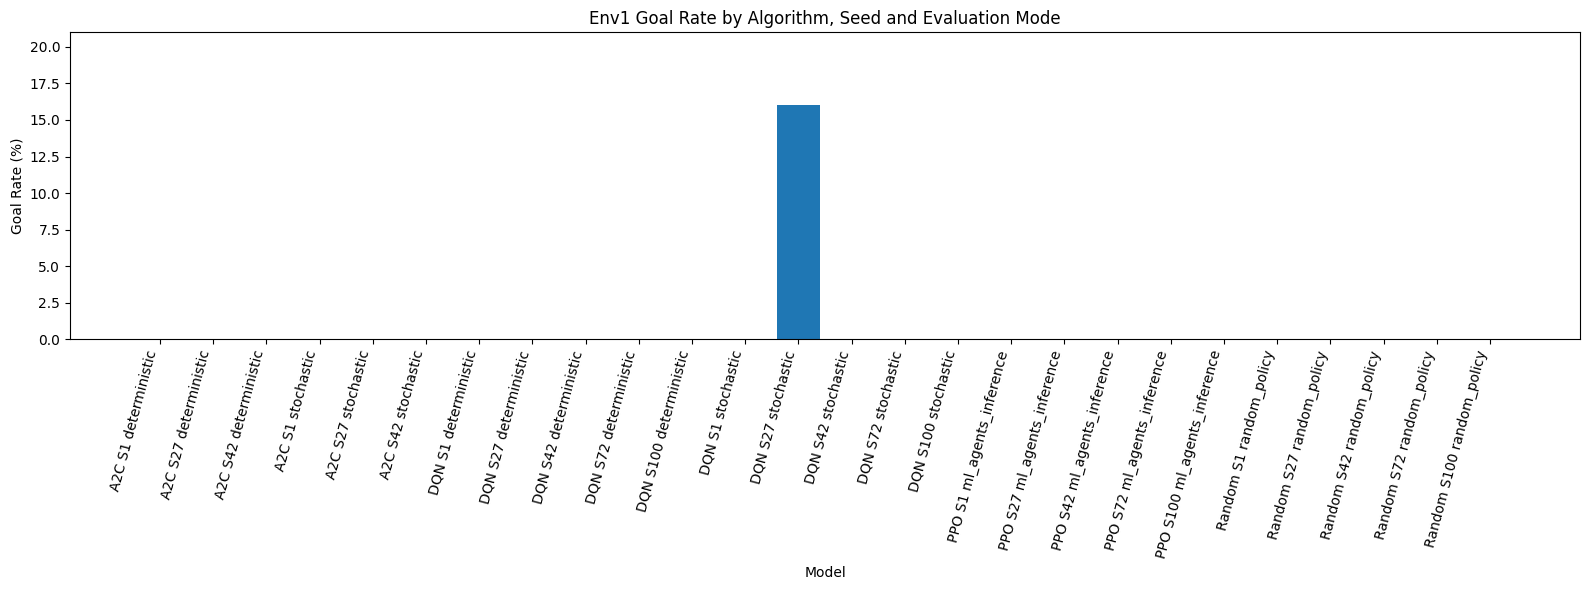

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/env1_goal_rate_by_model.png


In [31]:
env1_goal_df = env1_df.sort_values(
    by=["algorithm", "eval_mode", "seed"]
).copy()

plt.figure(figsize=(16, 6))
plt.bar(env1_goal_df["short_label"], env1_goal_df["goal_rate_pct"])
plt.title("Env1 Goal Rate by Algorithm, Seed and Evaluation Mode")
plt.xlabel("Model")
plt.ylabel("Goal Rate (%)")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, max(20, env1_goal_df["goal_rate_pct"].max() + 5))
plt.tight_layout()

figure_path = FIGURE_DIR / "env1_goal_rate_by_model.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure gespeichert:", show_project_path(figure_path))

---

### 11. Env1: Mean Reward nach Modell

Diese Abbildung vergleicht die durchschnittlichen Rewards in Env1.  
Höhere Werte sind besser.

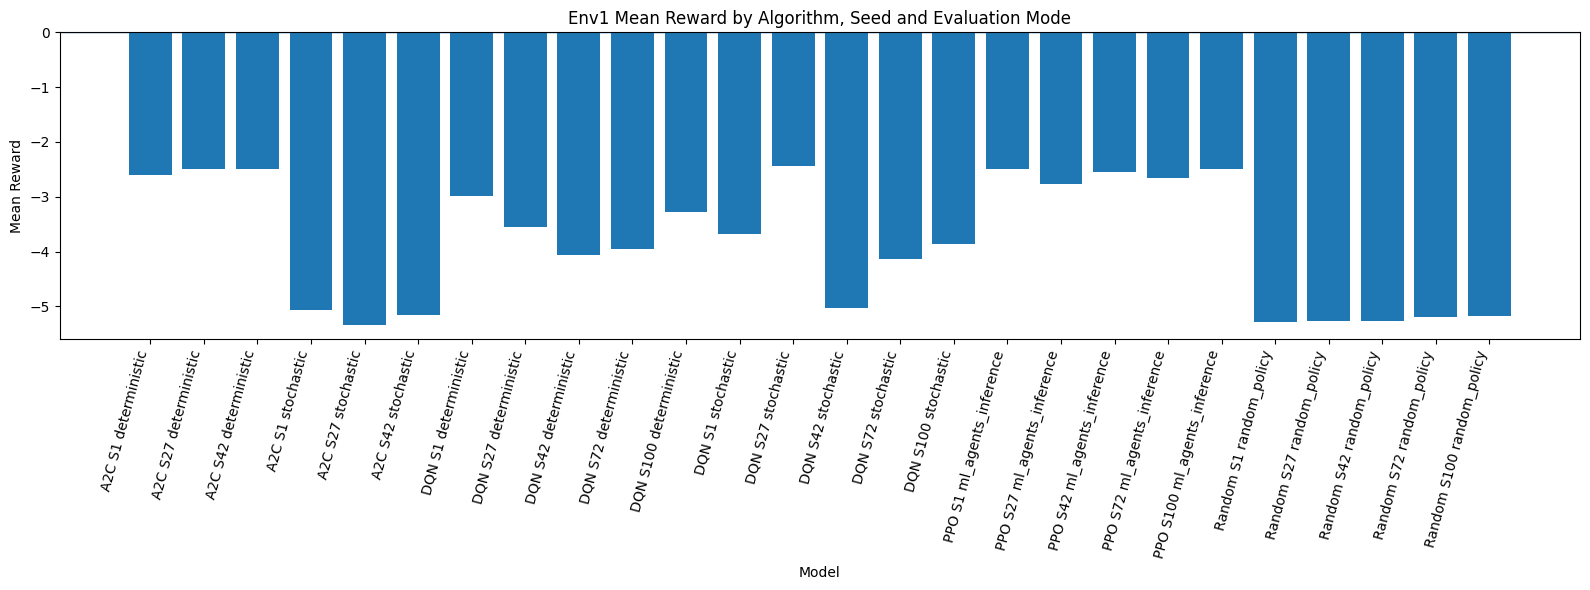

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/env1_mean_reward_by_model.png


In [32]:
env1_reward_df = env1_df.sort_values(
    by=["algorithm", "eval_mode", "seed"]
).copy()

plt.figure(figsize=(16, 6))
plt.bar(env1_reward_df["short_label"], env1_reward_df["mean_reward"])
plt.title("Env1 Mean Reward by Algorithm, Seed and Evaluation Mode")
plt.xlabel("Model")
plt.ylabel("Mean Reward")
plt.xticks(rotation=75, ha="right")
plt.axhline(0, linewidth=1)
plt.tight_layout()

figure_path = FIGURE_DIR / "env1_mean_reward_by_model.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure gespeichert:", show_project_path(figure_path))

---

### 12. Env1: Timeout Rate nach Modell

Diese Abbildung zeigt, wie häufig die Agenten bis zum Episodenlimit liefen.  
Eine hohe Timeout Rate kann auf Lazy-Agent- oder Survival-Verhalten hinweisen, wenn gleichzeitig keine Goals erreicht werden.

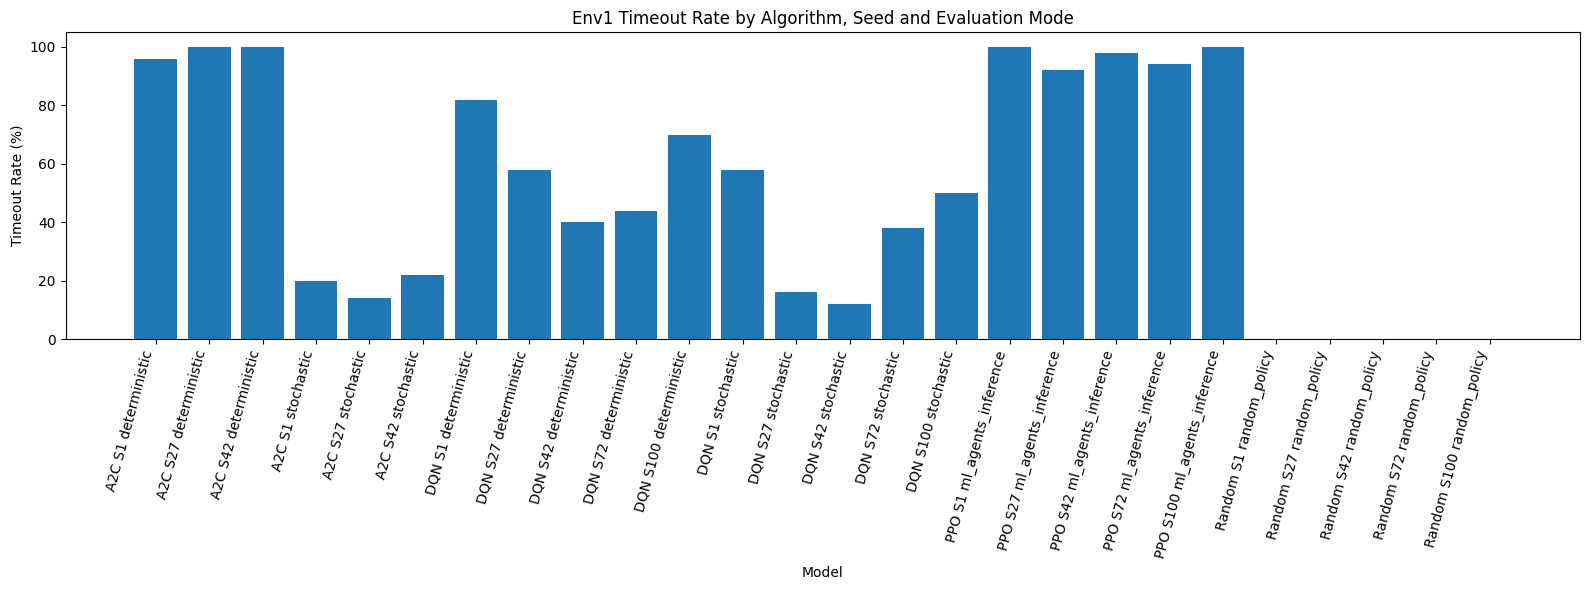

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/env1_timeout_rate_by_model.png


In [33]:
env1_timeout_df = env1_df.sort_values(
    by=["algorithm", "eval_mode", "seed"]
).copy()

plt.figure(figsize=(16, 6))
plt.bar(env1_timeout_df["short_label"], env1_timeout_df["timeout_rate_pct"])
plt.title("Env1 Timeout Rate by Algorithm, Seed and Evaluation Mode")
plt.xlabel("Model")
plt.ylabel("Timeout Rate (%)")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 105)
plt.tight_layout()

figure_path = FIGURE_DIR / "env1_timeout_rate_by_model.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure gespeichert:", show_project_path(figure_path))

---

### 13. Env1: Wall-like Failure Rate nach Modell

Diese Abbildung zeigt, wie häufig Episoden in Wall-like Failures endeten.  
Für Random und PPO werden die Flags aus dem Unity EpisodeLogger verwendet.

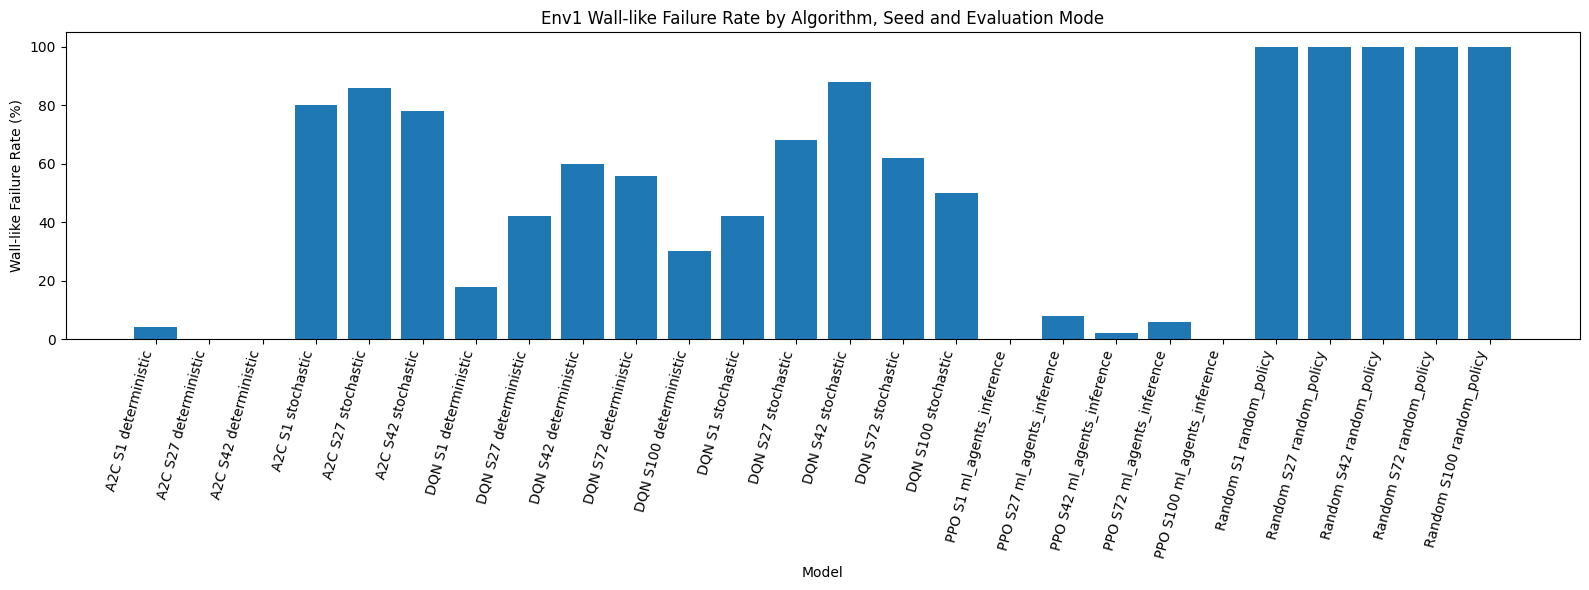

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/env1_wall_like_failure_rate_by_model.png


In [34]:
env1_wall_df = env1_df.sort_values(
    by=["algorithm", "eval_mode", "seed"]
).copy()

plt.figure(figsize=(16, 6))
plt.bar(env1_wall_df["short_label"], env1_wall_df["wall_like_rate_pct"])
plt.title("Env1 Wall-like Failure Rate by Algorithm, Seed and Evaluation Mode")
plt.xlabel("Model")
plt.ylabel("Wall-like Failure Rate (%)")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 105)
plt.tight_layout()

figure_path = FIGURE_DIR / "env1_wall_like_failure_rate_by_model.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure gespeichert:", show_project_path(figure_path))

---

### 14. Deterministic vs. Stochastic bei A2C und DQN

Diese Tabelle und Abbildung vergleichen die Evaluationsmodi für A2C und DQN in Env1.  
Bei DQN ist diese Unterscheidung besonders relevant, weil nur DQN Seed 27 im stochastischen Modus Goals erreicht hat.

In [35]:
sb3_env1_df = env1_df[
    env1_df["algorithm"].isin(["A2C", "DQN"])
].copy()

mode_comparison_df = (
    sb3_env1_df
    .groupby(["algorithm", "eval_mode"])
    .agg(
        mean_goal_rate=("goal_rate", "mean"),
        mean_reward=("mean_reward", "mean"),
        mean_timeout_rate=("timeout_rate", "mean"),
        mean_wall_like_rate=("wall_like_rate", "mean"),
    )
    .reset_index()
)

mode_comparison_df["mean_goal_rate_pct"] = mode_comparison_df["mean_goal_rate"] * 100
mode_comparison_df["mean_timeout_rate_pct"] = mode_comparison_df["mean_timeout_rate"] * 100
mode_comparison_df["mean_wall_like_rate_pct"] = mode_comparison_df["mean_wall_like_rate"] * 100

display(mode_comparison_df)

,algorithm,eval_mode,mean_goal_rate,mean_reward,mean_timeout_rate,mean_wall_like_rate,mean_goal_rate_pct,mean_timeout_rate_pct,mean_wall_like_rate_pct
0,A2C,deterministic,0.000,-2.536013,0.986667,0.013333,0.0,98.666667,1.333333
1,A2C,stochastic,0.000,-5.181377,0.186667,0.813333,0.0,18.666667,81.333333
2,DQN,deterministic,0.000,-3.568214,0.588000,0.412000,0.0,58.800000,41.200000
3,DQN,stochastic,0.032,-3.825380,0.348000,0.620000,3.2,34.800000,62.000000


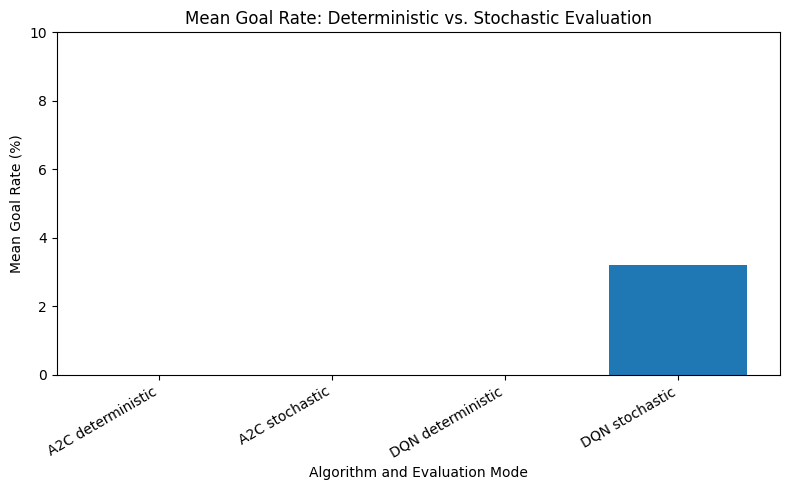

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/deterministic_vs_stochastic_goal_rate.png


In [36]:
mode_comparison_plot_df = mode_comparison_df.copy()
mode_comparison_plot_df["label"] = (
    mode_comparison_plot_df["algorithm"]
    + " "
    + mode_comparison_plot_df["eval_mode"]
)

plt.figure(figsize=(8, 5))
plt.bar(mode_comparison_plot_df["label"], mode_comparison_plot_df["mean_goal_rate_pct"])
plt.title("Mean Goal Rate: Deterministic vs. Stochastic Evaluation")
plt.xlabel("Algorithm and Evaluation Mode")
plt.ylabel("Mean Goal Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(10, mode_comparison_plot_df["mean_goal_rate_pct"].max() + 5))
plt.tight_layout()

figure_path = FIGURE_DIR / "deterministic_vs_stochastic_goal_rate.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure gespeichert:", show_project_path(figure_path))

---

### 15. Best Models für Transfer laden oder rekonstruieren

Diese Tabelle zeigt die ausgewählten Best Models für die Transfer-Evaluation.

Die Auswahl basiert auf der Env1-Performance und folgt den Kriterien, die auch im Notebook 06 bei der Auswahl der Best Models für Env1 verwendet wurden:

1. höchste Goal Rate
2. höchster Mean Reward
3. niedrigste Timeout Rate
4. niedrigste Wall-like Failure Rate
5. niedrigste Mean Episode Length

Bei PPO wurde bei vollständigem Gleichstand zwischen Seed 1 und Seed 100 der niedrigere Seed als technischer Tie-Breaker gewählt (Seed 1 wurde gewählt)

In [37]:
best_models_path = EVALUATION_TABLE_DIR / "best_models_for_transfer.csv"

if best_models_path.exists():
    best_models_df = pd.read_csv(best_models_path)
    print("Best Models geladen:")
    print(show_project_path(best_models_path))
else:
    print("Best-Models-Datei nicht gefunden. Tabelle wird aus evaluation_summary_df rekonstruiert.")

    def select_best_model_for_plot(df: pd.DataFrame, algorithm: str, eval_mode: str | None):
        sub = df[
            (df["algorithm"] == algorithm) &
            (df["eval_environment"] == "Env1")
        ].copy()

        if eval_mode is not None:
            sub = sub[sub["eval_mode"] == eval_mode]

        sub = sub.sort_values(
            by=["goal_rate", "mean_reward", "timeout_rate", "wall_like_rate", "mean_steps", "seed"],
            ascending=[False, False, True, True, True, True],
        )

        return sub.iloc[0]

    best_rows = [
        ("best_A2C_deterministic", select_best_model_for_plot(plot_df, "A2C", "deterministic")),
        ("best_A2C_stochastic", select_best_model_for_plot(plot_df, "A2C", "stochastic")),
        ("best_DQN_deterministic", select_best_model_for_plot(plot_df, "DQN", "deterministic")),
        ("best_DQN_stochastic", select_best_model_for_plot(plot_df, "DQN", "stochastic")),
        ("best_PPO", select_best_model_for_plot(plot_df, "PPO", "ml_agents_inference")),
    ]

    best_models_df = pd.DataFrame([
        {"best_model_label": label, **row.to_dict()}
        for label, row in best_rows
    ])

    best_models_df.to_csv(best_models_path, index=False, encoding="utf-8")

display(best_models_df)

Best Models geladen:
rl_navigation_project/training/evaluation_results/tables/best_models_for_transfer.csv


,best_model_label,algorithm,analysis_run_id,seed,eval_environment,eval_mode,episodes,mean_reward,std_reward,mean_steps,std_steps,goals,timeouts,wall_like_failures,goal_rate,timeout_rate,wall_like_rate
0,best_A2C_deterministic,A2C,A2C_Seed27,27,Env1,deterministic,50,-2.50000,0.000000,5000.00,0.000000,0,50,0,0.00,1.00,0.00
1,best_A2C_stochastic,A2C,A2C_Seed1,1,Env1,stochastic,50,-5.05817,1.384765,2116.34,1764.598476,0,10,40,0.00,0.20,0.80
2,best_DQN_deterministic,DQN,DQN_v1_Seed1,1,Env1,deterministic,50,-2.97972,1.041913,4159.44,1829.650041,0,41,9,0.00,0.82,0.18
3,best_DQN_stochastic,DQN,DQN_v1_Seed27,27,Env1,stochastic,50,-2.43109,5.484505,1262.18,1865.061543,8,8,34,0.16,0.16,0.68
4,best_PPO,PPO,PPO_Seed1,1,Env1,ml_agents_inference,50,-2.49940,0.000000,4999.00,0.000000,0,50,0,0.00,1.00,0.00


---

### 16. Transfervergleich vorbereiten

Für die Transferplots werden die ausgewählten Best Models aus Env1 mit ihren Ergebnissen in Env2 und Env3 zusammengeführt.

Wichtig:
- Env1 ist die Trainingsumgebung
- Env2 und Env3 sind Transferumgebungen
- Random wurde in allen Environments über fünf Seeds evaluiert
- Die trainierten Modelle wurden in Env2 und Env3 nur mit den ausgewählten Best Models getestet

In [40]:
transfer_plot_rows = []

for _, row in best_models_df.iterrows():
    best_label = row["best_model_label"]
    algorithm = row["algorithm"]
    seed = int(row["seed"])
    eval_mode = row["eval_mode"]

    if best_label == "PPO_Seed1":
        transfer_rows = plot_df[
            (plot_df["algorithm"] == "PPO") &
            (
                ((plot_df["analysis_run_id"] == "PPO_Seed1") & (plot_df["eval_environment"] == "Env1")) |
                ((plot_df["analysis_run_id"] == "best_PPO") & (plot_df["eval_environment"].isin(["Env2", "Env3"])))
            )
        ].copy()
    else:
        transfer_rows = plot_df[
            (plot_df["algorithm"] == algorithm) &
            (plot_df["seed"] == seed) &
            (plot_df["eval_mode"] == eval_mode) &
            (plot_df["eval_environment"].isin(["Env1", "Env2", "Env3"]))
        ].copy()

    transfer_rows["best_model_label"] = best_label
    transfer_plot_rows.append(transfer_rows)

best_transfer_df = pd.concat(transfer_plot_rows, ignore_index=True)

best_transfer_df["env_order"] = best_transfer_df["eval_environment"].map({
    "Env1": 1,
    "Env2": 2,
    "Env3": 3,
})

best_transfer_df = best_transfer_df.sort_values(
    by=["best_model_label", "env_order"]
)

best_transfer_path = EVALUATION_TABLE_DIR / "best_model_transfer_summary.csv"
best_transfer_df.to_csv(best_transfer_path, index=False, encoding="utf-8")

print("Best Model Transfer Summary gespeichert:")
print(show_project_path(best_transfer_path))

display(best_transfer_df[[
    "best_model_label",
    "algorithm",
    "analysis_run_id",
    "seed",
    "eval_environment",
    "eval_mode",
    "goal_rate",
    "mean_reward",
    "timeout_rate",
    "wall_like_rate",
]])

Best Model Transfer Summary gespeichert:
rl_navigation_project/training/evaluation_results/tables/best_model_transfer_summary.csv


,best_model_label,algorithm,analysis_run_id,seed,eval_environment,eval_mode,goal_rate,mean_reward,timeout_rate,wall_like_rate
0,best_A2C_deterministic,A2C,A2C_Seed27,27,Env1,deterministic,0.00,-2.500000,1.00,0.00
1,best_A2C_deterministic,A2C,A2C_Seed27,27,Env2,deterministic,0.00,-4.855640,0.06,0.94
2,best_A2C_deterministic,A2C,A2C_Seed27,27,Env3,deterministic,0.00,-5.005300,0.00,1.00
3,best_A2C_stochastic,A2C,A2C_Seed1,1,Env1,stochastic,0.00,-5.058170,0.20,0.80
4,best_A2C_stochastic,A2C,A2C_Seed1,1,Env2,stochastic,0.00,-5.041960,0.00,1.00
5,best_A2C_stochastic,A2C,A2C_Seed1,1,Env3,stochastic,0.00,-5.046110,0.00,1.00
6,best_DQN_deterministic,DQN,DQN_v1_Seed1,1,Env1,deterministic,0.00,-2.979720,0.82,0.18
7,best_DQN_deterministic,DQN,DQN_v1_Seed1,1,Env2,deterministic,0.00,-3.310940,0.68,0.32
8,best_DQN_deterministic,DQN,DQN_v1_Seed1,1,Env3,deterministic,0.00,-4.488990,0.22,0.78
9,best_DQN_stochastic,DQN,DQN_v1_Seed27,27,Env1,stochastic,0.16,-2.431090,0.16,0.68


---

### 17. Transfer: Goal Rate der Best Models

Diese Abbildungen zeigen die Goal Rate der ausgewählten Best Models in Env1, Env2 und Env3.

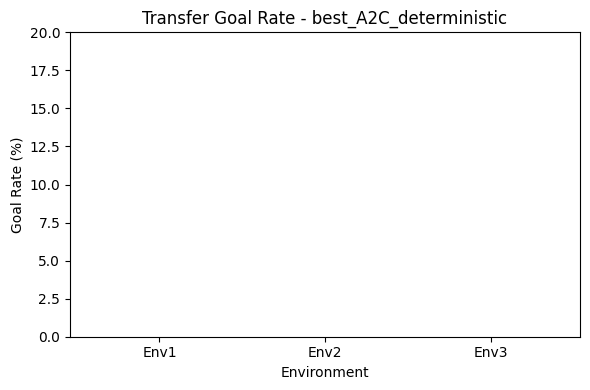

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_goal_rate_best_a2c_deterministic.png


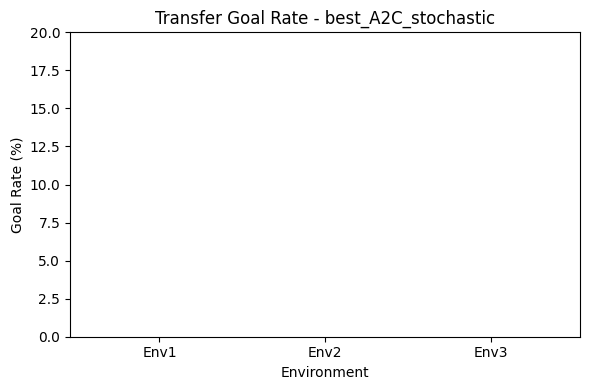

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_goal_rate_best_a2c_stochastic.png


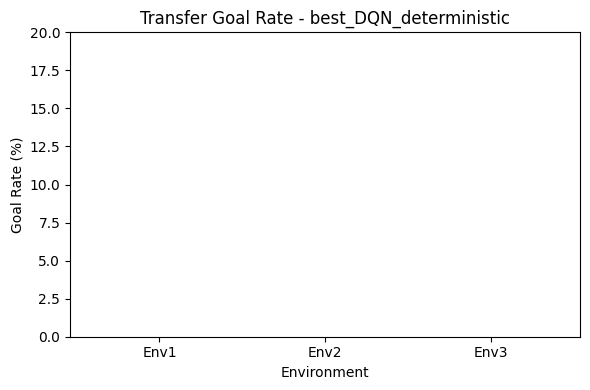

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_goal_rate_best_dqn_deterministic.png


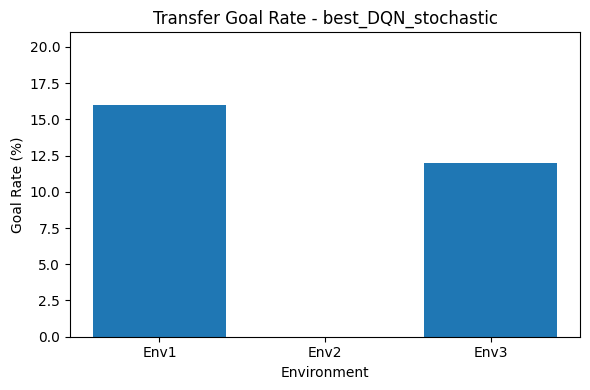

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_goal_rate_best_dqn_stochastic.png


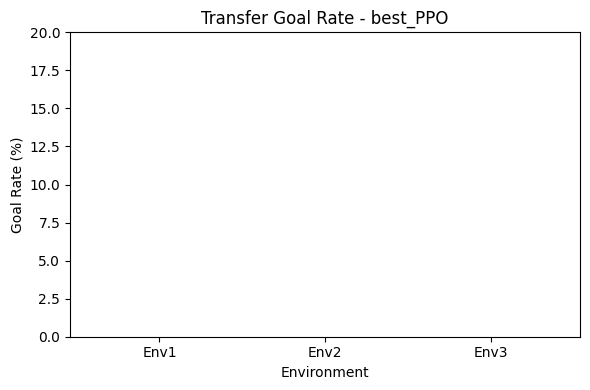

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_goal_rate_best_ppo.png


In [41]:
for best_model_label in best_transfer_df["best_model_label"].unique():
    sub_df = best_transfer_df[
        best_transfer_df["best_model_label"] == best_model_label
    ].sort_values("env_order")

    plt.figure(figsize=(6, 4))
    plt.bar(sub_df["eval_environment"], sub_df["goal_rate"] * 100)
    plt.title(f"Transfer Goal Rate - {best_model_label}")
    plt.xlabel("Environment")
    plt.ylabel("Goal Rate (%)")
    plt.ylim(0, max(20, (sub_df["goal_rate"] * 100).max() + 5))
    plt.tight_layout()

    safe_name = best_model_label.lower()
    figure_path = FIGURE_DIR / f"transfer_goal_rate_{safe_name}.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figure gespeichert:", show_project_path(figure_path))

---

### 18. Transfer: Mean Reward der Best Models

Diese Abbildungen zeigen den Mean Reward der ausgewählten Best Models in Env1, Env2 und Env3.

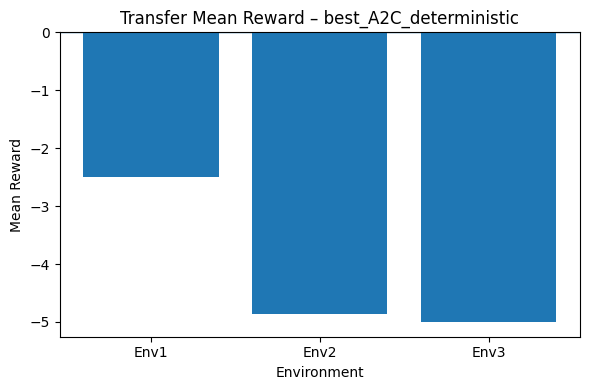

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_mean_reward_best_a2c_deterministic.png


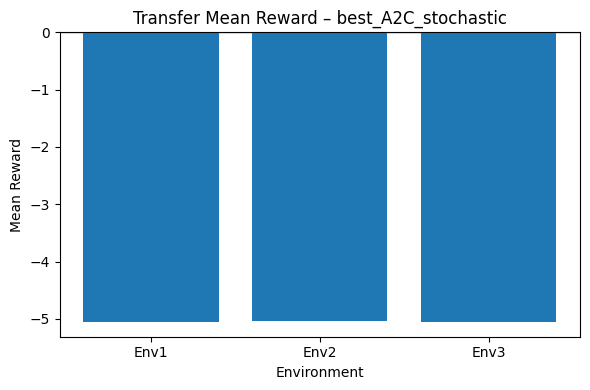

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_mean_reward_best_a2c_stochastic.png


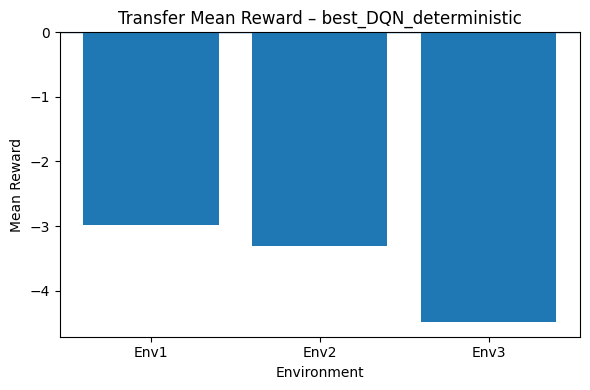

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_mean_reward_best_dqn_deterministic.png


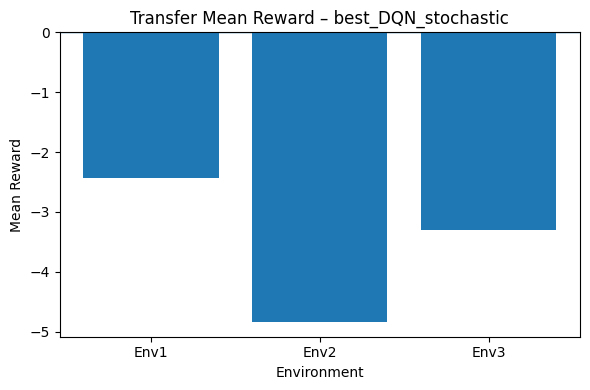

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_mean_reward_best_dqn_stochastic.png


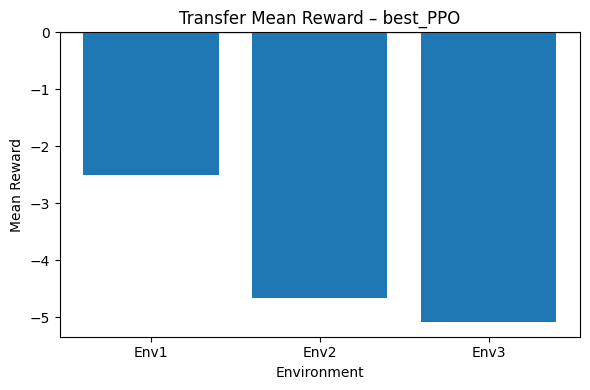

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/transfer_mean_reward_best_ppo.png


In [42]:
for best_model_label in best_transfer_df["best_model_label"].unique():
    sub_df = best_transfer_df[
        best_transfer_df["best_model_label"] == best_model_label
    ].sort_values("env_order")

    plt.figure(figsize=(6, 4))
    plt.bar(sub_df["eval_environment"], sub_df["mean_reward"])
    plt.title(f"Transfer Mean Reward – {best_model_label}")
    plt.xlabel("Environment")
    plt.ylabel("Mean Reward")
    plt.axhline(0, linewidth=1)
    plt.tight_layout()

    safe_name = best_model_label.lower()
    figure_path = FIGURE_DIR / f"transfer_mean_reward_{safe_name}.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figure gespeichert:", show_project_path(figure_path))

---

### 19. Random Baseline vs. Best Models

Dieser Vergleich stellt die aggregierte Random Baseline den transferierten Best Models gegenüber.

Wichtig:
- Random wurde für alle Environments über fünf Seeds ausgewertet
- Die trainierten Modelle wurden in Env2 und Env3 nur exemplarisch mit den ausgewählten Best Models evaluiert
- Der Vergleich in Env2 und Env3 ist daher nicht als vollständiger Seed-basierter Algorithmusvergleich zu verstehen

In [43]:
random_plot_df = random_summary_df.copy()
random_plot_df["model_label"] = "Random Baseline"
random_plot_df["goal_rate_pct"] = random_plot_df["mean_goal_rate"] * 100

best_transfer_goal_df = best_transfer_df.copy()
best_transfer_goal_df["model_label"] = best_transfer_goal_df["best_model_label"]
best_transfer_goal_df["goal_rate_pct"] = best_transfer_goal_df["goal_rate"] * 100

comparison_rows = []

for _, row in random_plot_df.iterrows():
    comparison_rows.append({
        "eval_environment": row["eval_environment"],
        "model_label": row["model_label"],
        "goal_rate_pct": row["goal_rate_pct"],
    })

for _, row in best_transfer_goal_df.iterrows():
    comparison_rows.append({
        "eval_environment": row["eval_environment"],
        "model_label": row["model_label"],
        "goal_rate_pct": row["goal_rate_pct"],
    })

random_vs_best_df = pd.DataFrame(comparison_rows)

display(random_vs_best_df)

,eval_environment,model_label,goal_rate_pct
0,Env1,Random Baseline,0.0
1,Env2,Random Baseline,0.0
2,Env3,Random Baseline,0.4
3,Env1,best_A2C_deterministic,0.0
4,Env2,best_A2C_deterministic,0.0
5,Env3,best_A2C_deterministic,0.0
6,Env1,best_A2C_stochastic,0.0
7,Env2,best_A2C_stochastic,0.0
8,Env3,best_A2C_stochastic,0.0
9,Env1,best_DQN_deterministic,0.0


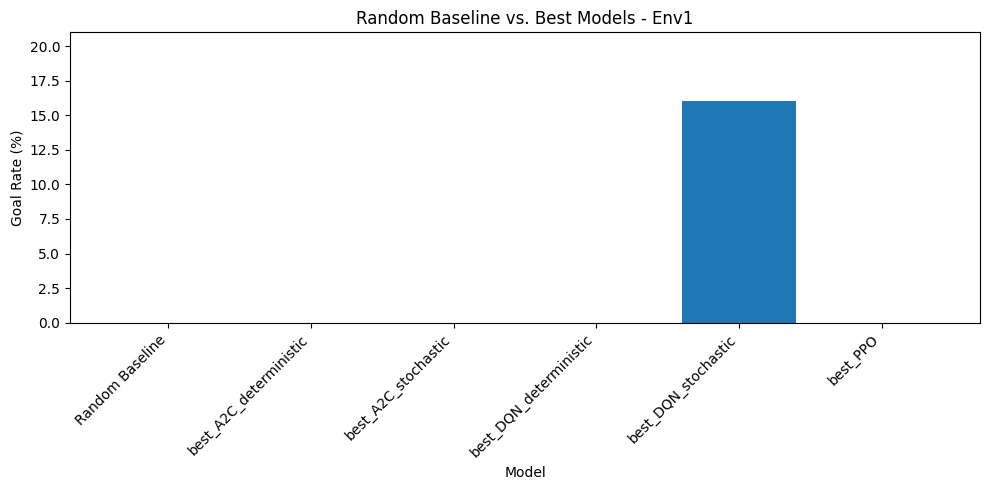

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/random_vs_best_goal_rate_env1.png


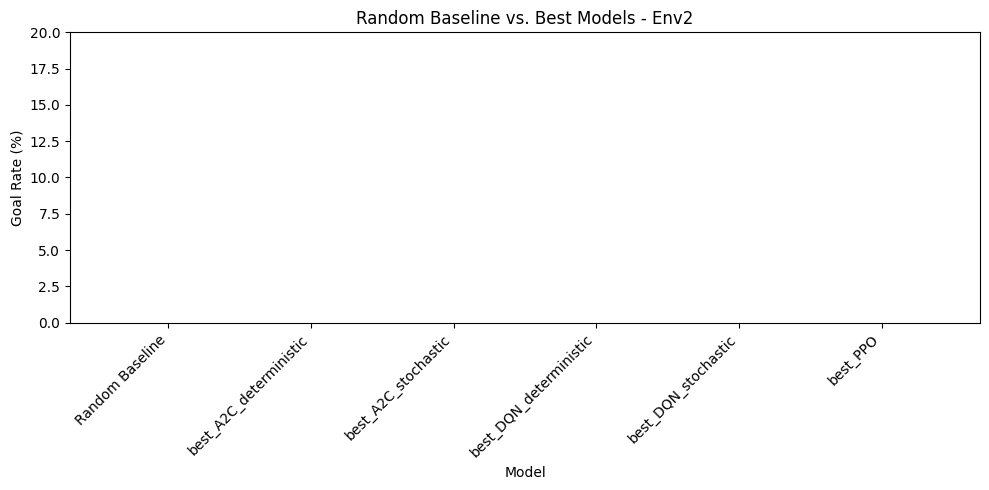

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/random_vs_best_goal_rate_env2.png


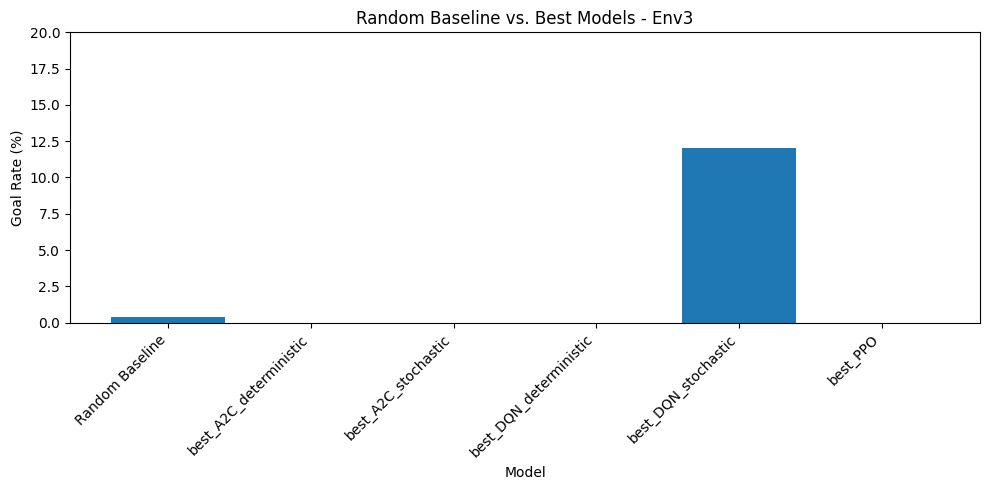

Figure gespeichert: rl_navigation_project/training/evaluation_results/figures/random_vs_best_goal_rate_env3.png


In [45]:
for env_name in ["Env1", "Env2", "Env3"]:
    sub_df = random_vs_best_df[
        random_vs_best_df["eval_environment"] == env_name
    ].copy()

    plt.figure(figsize=(10, 5))
    plt.bar(sub_df["model_label"], sub_df["goal_rate_pct"])
    plt.title(f"Random Baseline vs. Best Models - {env_name}")
    plt.xlabel("Model")
    plt.ylabel("Goal Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, max(20, sub_df["goal_rate_pct"].max() + 5))
    plt.tight_layout()

    figure_path = FIGURE_DIR / f"random_vs_best_goal_rate_{env_name.lower()}.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figure gespeichert:", show_project_path(figure_path))

---

### 20. Kompakte Ergebnisübersicht speichern

Diese Tabelle enthält die wichtigsten Kennzahlen für die spätere schriftliche Auswertung.

In [46]:
compact_results_df = plot_df[[
    "algorithm",
    "analysis_run_id",
    "seed",
    "eval_environment",
    "eval_mode",
    "episodes",
    "goals",
    "goal_rate",
    "mean_reward",
    "timeouts",
    "timeout_rate",
    "wall_like_failures",
    "wall_like_rate",
    "mean_steps",
]].copy()

compact_results_path = EVALUATION_TABLE_DIR / "compact_evaluation_results.csv"
compact_results_df.to_csv(compact_results_path, index=False, encoding="utf-8")

print("Kompakte Ergebnisübersicht gespeichert:")
print(show_project_path(compact_results_path))

display(compact_results_df)

Kompakte Ergebnisübersicht gespeichert:
rl_navigation_project/training/evaluation_results/tables/compact_evaluation_results.csv


,algorithm,analysis_run_id,seed,eval_environment,eval_mode,episodes,goals,goal_rate,mean_reward,timeouts,timeout_rate,wall_like_failures,wall_like_rate,mean_steps
0,A2C,A2C_Seed1,1,Env1,deterministic,50,0,0.00,-2.608040,48,0.96,2,0.04,4816.08
1,A2C,A2C_Seed1,1,Env1,stochastic,50,0,0.00,-5.058170,10,0.20,40,0.80,2116.34
2,A2C,A2C_Seed1,1,Env2,stochastic,50,0,0.00,-5.041960,0,0.00,50,1.00,83.92
3,A2C,A2C_Seed1,1,Env3,stochastic,50,0,0.00,-5.046110,0,0.00,50,1.00,92.22
4,A2C,A2C_Seed27,27,Env1,deterministic,50,0,0.00,-2.500000,50,1.00,0,0.00,5000.00
5,A2C,A2C_Seed27,27,Env1,stochastic,50,0,0.00,-5.329870,7,0.14,43,0.86,2059.74
6,A2C,A2C_Seed27,27,Env2,deterministic,50,0,0.00,-4.855640,3,0.06,47,0.94,311.28
7,A2C,A2C_Seed27,27,Env3,deterministic,50,0,0.00,-5.005300,0,0.00,50,1.00,10.60
8,A2C,A2C_Seed42,42,Env1,deterministic,50,0,0.00,-2.500000,50,1.00,0,0.00,5000.00
9,A2C,A2C_Seed42,42,Env1,stochastic,50,0,0.00,-5.156090,11,0.22,39,0.78,2512.18


---

### Finale Erkenntnisse aus der Evaluation

Die finale Evaluation zeigt insgesamt, dass keine der getesteten Methoden eine robuste Zielnavigation über alle Environments gelernt hat. Die Ergebnisse unterscheiden sich jedoch deutlich hinsichtlich Fehlerverhalten, Seed-Abhängigkeit und Transferfähigkeit.

#### 1. Random Baseline als untere Vergleichsgröße

Die Random Baseline erreicht in fast allen Runs keine Goals. Nur in Env3 bei Seed 27 wurde ein einzelnes Goal erreicht, was einer Goal Rate von 2 % entspricht. In allen anderen Random-Runs liegt die Goal Rate bei 0 %.

Die Random Baseline endet fast ausschließlich in Wall-like Failures. Besonders in Env2 und Env3 liegen die mittleren Episode Steps meist nur zwischen ca. 90 und 180 Schritten. Das zeigt, dass zufälliges Verhalten sehr schnell gegen Wände führt und keine stabile Navigation ermöglicht.

Damit dient die Random Baseline als sinnvolle untere Vergleichsgröße: Ein trainierter Agent sollte entweder mehr Goals erreichen, länger überleben oder systematisch bessere Rewards erzielen.

#### 2. A2C lernt keine erfolgreiche Zielnavigation

A2C erreicht in keiner evaluierten Konfiguration ein Goal. Die Goal Rate liegt sowohl in Env1 als auch in den Transferumgebungen Env2 und Env3 bei 0 %.

Dabei zeigt sich ein deutlicher Unterschied zwischen deterministischer und stochastischer Evaluation:

- Deterministische A2C-Runs in Env1 führen häufig zu Timeouts. Seed 27 und Seed 42 laufen in allen 50 Episoden bis zum Timeout und erreichen einen Mean Reward von -2.5.
- Stochastische A2C-Runs führen deutlich häufiger zu Wall-like Failures. Die Wall-like Failure Rate liegt in Env1 zwischen 78 % und 86 %.

In den Transferumgebungen verschlechtert sich das Verhalten weiter. A2C endet dort fast ausschließlich in Wall-like Failures. Damit zeigt A2C keine verwertbare Transferfähigkeit.

#### 3. PPO entwickelt vor allem Lazy-/Survival-Verhalten, aber keine Zielnavigation

PPO erreicht in Env1 bei keinem Seed ein Goal. Die Goal Rate liegt für alle PPO-Seeds bei 0 %.

Besonders auffällig sind PPO Seed 1 und PPO Seed 100. Beide laufen in allen 50 Episoden bis zum Timeout, ohne Goals oder Wall-Hits zu erzeugen. Das spricht für ein Lazy- oder Survival-Verhalten >> Der Agent vermeidet negative Ereignisse, erreicht aber auch nicht das Ziel.

Die PPO-Transferergebnisse bestätigen dieses Problem. Das ausgewählte PPO-Modell aus Seed 1 erreicht auch in Env2 und Env3 keine Goals. In Env2 endet es in 86 % der Episoden in Wall-like Failures, in Env3 sogar in 100 %. Damit ist PPO zwar in Env1 teilweise stabil im Sinne von Wandvermeidung, aber nicht zielorientiert und nicht transferfähig.

#### 4. DQN ist stark seed- und modusabhängig

DQN zeigt die interessantesten, aber auch instabilsten Ergebnisse. In der deterministischen Evaluation erreicht kein DQN-Seed in Env1 ein Goal. Die Goal Rate liegt überall bei 0 %.

Erst im stochastischen Modus zeigt DQN Seed 27 erfolgreiches Zielverhalten:

- Env1: 8 von 50 Goals, also 16 % Goal Rate
- Env2: 0 von 50 Goals, also 0 % Goal Rate
- Env3: 6 von 50 Goals, also 12 % Goal Rate

Damit ist DQN Seed 27 stochastic das einzige Modell, das in mehr als einer Umgebung Goals erreicht. Gleichzeitig bleibt das Verhalten instabil: In Env1 endet DQN Seed 27 stochastic in 68 % der Episoden in Wall-like Failures, in Env2 in 88 % und in Env3 in 86 %.

DQN zeigt damit als einziger Algorithmus Hinweise auf gelernte Zielnavigation, aber keine robuste Policy.

#### 5. Deterministische Evaluation reicht in diesem Projekt nicht aus

Die Ergebnisse zeigen deutlich, dass eine rein deterministische Evaluation wichtige Verhaltensunterschiede verdecken würde. Besonders DQN Seed 27 erreicht nur im stochastischen Modus Goals.

Deterministisch bleibt derselbe Seed in Env1 bei 0 % Goal Rate. Stochastisch erreicht er 16 %. Das unterstützt die Beobachtung, dass die greedy Policy in bestimmten Zuständen zu ineffektiven oder eingefrorenen Verhaltensmustern führen kann, während stochastische Action-Auswahl gelegentlich zielführende Aktionen ermöglicht.

Die Trennung zwischen deterministic und stochastic ist daher methodisch notwendig und nicht nur eine technische Zusatzanalyse.

#### 6. Transferfähigkeit ist nur eingeschränkt vorhanden

Die Transfer-Evaluation zeigt keine robuste Generalisierung auf neue Environments. A2C und PPO erreichen in Env2 und Env3 keine Goals. DQN Seed 27 stochastic erreicht in Env3 zwar 6 Goals, scheitert aber vollständig in Env2.

Das spricht dafür, dass das gelernte Verhalten nicht allgemein robust ist, sondern stark von Environment-Struktur, Seed und Evaluationsmodus abhängt.

Besonders Env2 scheint für das beste DQN-Modell problematisch zu sein: Trotz 16 % Goal Rate in Env1 fällt die Goal Rate in Env2 auf 0 %. In Env3 steigt sie wieder auf 12 %, was eher auf instabile, situationsabhängige Teilnavigation als auf echte Generalisierung hindeutet.

#### 7. Gesamtfazit

Die Evaluation zeigt kein klar erfolgreiches RL-System im Sinne einer stabilen Zielnavigation. Der wichtigste positive Befund ist DQN Seed 27 im stochastischen Modus, da dieses Modell als einziges nennenswerte Goal Rates in Env1 und Env3 erreicht.

Gleichzeitig zeigen die Ergebnisse drei zentrale Herausforderungen des Projekts:

1. Reward Engineering: Viele Agenten lernen, Strafen zu vermeiden, aber nicht aktiv das Ziel zu erreichen.
2. Seed-Sensitivität: DQN zeigt starke Unterschiede zwischen Seeds.
3. Evaluationsmodus: Deterministische und stochastische Evaluation führen bei DQN zu deutlich unterschiedlichen Ergebnissen.

Damit ist das Ergebnis wissenschaftlich eher als kritische Analyse der Schwierigkeiten von RL in einer Unity-Navigationsumgebung zu interpretieren, nicht als Nachweis eines robust gelösten Navigationsproblems.

---

### Limitationen der Evaluation und Umsetzung

Die Ergebnisse dieser Arbeit müssen vor dem Hintergrund mehrerer methodischer, technischer und experimenteller Einschränkungen interpretiert werden.

#### 1. Begrenzte Episodenzahl in der finalen Evaluation

- die finale Evaluation wurde auf 50 Episoden pro Run reduziert
- ursprünglich waren 200 Episoden pro Run geplant
- die Reduktion war notwendig, weil die Evaluation einzelner Runs teilweise sehr lange dauerte (> 5 1/2 Stunden pro Run)
- dadurch sind Goal Rates, Timeout Rates und Wall-like Failure Rates weniger stabil geschätzt
- besonders bei niedrigen Erfolgsraten, z. B. 8/50 Goals bei DQN Seed 27 stochastic, ist die statistische Unsicherheit hoch
- die Ergebnisse zeigen daher Tendenzen, aber keine hochpräzisen Performance-Schätzungen

#### 2. Random Baseline wurde nachträglich angepasst

- die Random Baseline wurde ursprünglich mit 200 Episoden pro Run erzeugt
- für die finale Vergleichbarkeit wurden nur die ersten 50 Episoden je Random-Run verwendet
- die Random Baseline wurde außerdem zu einem früheren Zeitpunkt mit einer anderen Reward-Logik erzeugt
- deshalb wurde der Reward der Random Baseline nachträglich nach der finalen Reward-Logik neu berechnet
- diese Harmonisierung verbessert die Vergleichbarkeit, bleibt aber eine nachträgliche Anpassung der Datenbasis

#### 3. A2C wurde nur mit drei Seeds trainiert

- A2C wurde nur mit drei Seeds trainiert und evaluiert
- Grund dafür war, dass die ersten A2C-Ergebnisse keine Hinweise auf erfolgreiches Lernen gezeigt haben
- trotzdem ist diese Entscheidung methodisch eingeschränkt
- da die Ergebnisse insgesamt seedabhängig sind (siehe Limitation 4), kann nicht vollständig ausgeschlossen werden, dass weitere Seeds wie 72 oder 100 bessere Ergebnisse geliefert hätten
- die Aussage zu A2C ist daher auf die getesteten drei Seeds begrenzt
- A2C kann in dieser Arbeit nicht als vollständig ausgeschöpft oder abschließend optimiert betrachtet werden

#### 4. Seed-Sensitivität der Ergebnisse

- die Ergebnisse zeigen eine deutliche Seed-Abhängigkeit
- besonders DQN erreicht nur bei Seed 27 im stochastischen Modus nennenswerte Goals
- andere DQN-Seeds zeigen keine erfolgreiche Zielnavigation
- dadurch ist die Aussagekraft einzelner Best-Model-Ergebnisse begrenzt
- eine robustere Bewertung hätte mehr Seeds oder mehrere unabhängige Wiederholungen pro Konfiguration benötigt
- die starke Seed-Sensitivität ist selbst ein wichtiges Ergebnis, limitiert aber gleichzeitig die Generalisierbarkeit

#### 5. Begrenzter Nutzen des Optuna-Tunings und anschließende manuelle Modellkonfiguration

- im Projekt wurde Optuna eingesetzt, um Hyperparameter zu testen
- die durch Optuna vorgeschlagenen Konfigurationen führten jedoch nicht zu ausreichend guten / stabilen Ergebnissen
- aus diesem Grund wurden die finalen Modelle nicht direkt aus den besten Optuna-Trials übernommen
- stattdessen wurden anschließend manuelle Modellkonfigurationen erstellt und trainiert
- diese Entscheidung war pragmatisch notwendig, reduziert aber die methodische Strenge der Hyperparameter-Optimierung
- die finalen Hyperparameter sind daher nicht als Ergebnis einer vollständig erfolgreichen automatisierten Optimierung zu verstehen
- Optuna hatte in diesem Projekt eher explorativen Charakter und zeigte vor allem, dass die getesteten Suchräume und Trainingslängen keine robusten Modellverbesserungen lieferten
- eine belastbarere Hyperparameter-Optimierung hätte mehr Trials, längere Trainingsläufe, mehrere Seeds pro Trial und vermutlich eine stabilere Reward-Struktur benötigt

#### 6. Begrenztes Reward Engineering und Sparse-Reward-Problem

- die Navigationsaufgabe enthält ein Sparse-Reward-Problem
- der wichtigste positive Reward entsteht erst beim Erreichen des Goals
- gerade zu Beginn des Trainings erreicht der Agent das Ziel jedoch nur selten oder gar nich
- dadurch erhält der Agent nur wenige positive Lernsignale
- das Lernen wird daher stark durch negative Signale wie Wall Penalty, Timeout (max. Steps) und Step Penalty geprägt
- diese Struktur kann dazu führen, dass Agenten nicht aktiv zielgerichtetes Verhalten lernen, sondern lediglich versuchen, negative Ereignisse zu vermeiden
- das beobachtete Lazy-Agent-Verhalten bei PPO passt zu dieser Problematik: 
    - Der Agent vermeidet teilweise Wall-Hits, erreicht aber trotzdem keine Goals
- gleichzeitig kann eine zu starke Wall Penalty riskante Exploration unterdrücken, weil frühe Wandkollisionen stärker bestraft werden als langes passives Überleben
- die finale Reward-Struktur war daher eine begründete, aber weiterhin experimentelle Designentscheidung
- eine robustere Lösung hätte möglicherweise zusätzliche Reward-Shaping-Komponenten benötigt, z. B. Distanz-zum-Ziel-Belohnung, Fortschrittsreward oder Curriculum Learning

#### 7. Begrenztes Experimental Design

- das gesamte Experimental Design ist eine Vereinfachung der Navigationsaufgabe
- die Agenten hatten einen diskreten Action Space mit 9 Aktionen
- diese Aktionskodierung ermöglicht kombinierte Bewegungen, ist aber dennoch eine starke Vereinfachung gegenüber kontinuierlicher Steuerung
- die gewählte Action-Struktur kann bestimmte Verhaltensmuster begünstigen, z. B. No-op, Drehen, Oszillation oder ineffektive Bewegungsmuster
- die maximale Episodenlänge von 5000 Steps beeinflusst die Ergebnisse stark
- ein langer Timeout kann Survival-Verhalten belohnen, wenn der Agent Strafen vermeidet, aber das Ziel nicht erreicht
- die Step Penalty war relativ klein, wodurch langes Überleben teilweise weniger stark bestraft wurde als frühe Wall-Fails 
    - Wall-hits führen zu -5, Step Penalty zu -0.0005 pro Step -> Max Step Penalty bei 5000 Steps = -2.5
- dadurch können Lazy-Agent-Strategien entstehen, die aus Reward-Sicht weniger schlecht sind als aktive, aber riskante Exploration

#### 8. Unterschiedliche Evaluationsmechanismen zwischen PPO und SB3

- A2C und DQN wurden über Stable-Baselines3 aus Python heraus evaluiert
- PPO wurde über Unity ML-Agents Inference mit ONNX-Modellen evaluiert
- dadurch unterscheiden sich die technischen Evaluationspipelines
- für A2C und DQN konnte explizit zwischen deterministic und stochastic unterschieden werden
- PPO wurde dagegen über die native Unity-Inference-Pipeline bewertet
- ein direkter 1:1-Vergleich der Evaluationsmodi zwischen PPO und A2C/DQN ist daher nur eingeschränkt möglich
- PPO ist trotzdem inhaltlich vergleichbar, aber technisch nicht identisch evaluiert

#### 9. Nachträglicher ONNX-Export für PPO

- die PPO-Modelle lagen nach dem Training zunächst nur als PyTorch-Checkpoints vor
- für die Unity-Inference-Evaluation mussten sie nachträglich als ONNX-Dateien exportiert werden
- der Export erfolgte über `mlagents-learn --resume`
- dieser Schritt wurde nicht als neues Training genutzt, sondern nur zur Erzeugung der Inference-Modelle
- trotzdem stellt der nachträgliche Export eine zusätzliche technische Verarbeitung dar
- PPO wurde daher nicht über dieselbe Modelllade- und Evaluationspipeline wie A2C und DQN ausgewertet

#### 10. Deterministic vs. Stochastic Evaluation

- bei A2C und DQN wurde zwischen deterministischer und stochastischer Evaluation unterschieden
- Entscheidung wurde getroffen, weil bei DQN ein Frozen-Agent-Verhalten in Zielnähe beobachtet wurde
- DQN Seed 27 erreichte deterministisch keine Goals, aber stochastisch 8/50 Goals in Env1
- der Evaluationsmodus hat also einen Einfluss auf die gemessene Performance
- dadurch ist die Interpretation der „besten“ Policy nicht eindeutig
- deterministische Evaluation prüft die greedy Policy
- stochastische Evaluation zeigt eher, ob grundsätzlich zielrelevantes Verhalten gelernt wurde
- beide Sichtweisen sind relevant, aber sie messen nicht exakt dasselbe

#### 11. Transfer-Evaluation nur mit ausgewählten Best Models

- Env2 und Env3 wurden nicht für alle Algorithmen, Seeds und Modi vollständig evaluiert
- stattdessen wurden nur die aus Env1 ausgewählten Best Models übertragen
- dadurch ist die Transfer-Evaluation exemplarisch und nicht vollständig
- der Vergleich in Env2 und Env3 ist deshalb kein vollständiger Seed-basierter Algorithmusvergleich
- besonders Random wurde in Env2 und Env3 über fünf Seeds ausgewertet, während die trainierten Modelle dort nur mit ausgewählten Best Models getestet wurden
- die Transfer-Ergebnisse zeigen daher eher eingeschränkte Generalisierung einzelner Best Models als eine vollständige Generalisierungsanalyse

#### 12. Unterschiedliche Vergleichbarkeit zwischen Env1, Env2 und Env3

- Env1 war die Trainingsumgebung
- Env2 und Env3 waren Transferumgebungen
- die Environments unterscheiden sich in Struktur, Schwierigkeit und möglicher Navigation
- dadurch sind Performance-Unterschiede zwischen Env1, Env2 und Env3 nicht ausschließlich auf die Modellqualität zurückzuführen
- Env2 scheint für das beste DQN-Modell schwieriger gewesen zu sein als Env3
- eine separate quantitative Schwierigkeitsanalyse der Environments wurde nicht durchgeführt, wobei die Environements nach dem obenbeschriebenen Konzept erstellt wurden

#### 13. Vereinfachte Erfolgsklassifikation

- die Auswertung basiert auf Goal Rate, Timeout Rate, Wall-like Failure Rate, Mean Reward und Mean Steps
- für PPO und Random konnten Success-, Wall- und Timeout-Flags direkt aus dem Unity Logger genutzt werden
- für A2C und DQN wurden diese Größen teilweise aus Reward und Steps abgeleitet
- diese Klassifikation ist für die Auswertung praktikabel, ersetzt aber keine vollständige Analyse der Agenten-Trajektorien
- besonders Verhaltensmuster wie Kreisbewegungen, Stehenbleiben oder Oszillation werden durch aggregierte Metriken nur indirekt sichtbar

#### 14. Keine vollständige Trajektorien- und Action-Analyse

- die Evaluation enthält zwar aggregierte Action Counts für A2C und DQN
- eine vollständige Analyse der Bewegungsbahnen, Positionen und Zustände wurde jedoch nicht durchgeführt
- dadurch kann das genaue Verhalten der Agenten nur teilweise erklärt werden
- das Frozen-Agent-Verhalten wurde qualitativ beobachtet und durch Action Counts gestützt, aber nicht durch eine ovllständige State-/Q-Value-Analyse belegt
- eine detaillierte Trajektorienanalyse hätte zusätzliche Einsichten geliefert

#### 15. Begrenzte Trainingsdauer

- Die Trainingsläufe wurden mit festen Step-Budgets durchgeführt.
- Es ist möglich, dass längeres Training zu anderen Ergebnissen geführt hätte.
- Gleichzeitig zeigten manche Algorithmen bereits klare problematische Tendenzen, z. B. A2C ohne Lernfortschritt oder PPO mit Lazy-Agent-Verhalten.
- Trotzdem kann nicht ausgeschlossen werden, dass einzelne Algorithmen bei längerer Trainingszeit bessere Policies gelernt hätten.

#### 16. Keine vollständige Vergleichbarkeit zwischen Algorithmen

- A2C und DQN wurden über Stable-Baselines3 trainiert.
- PPO wurde über Unity ML-Agents trainiert.
- Dadurch unterscheiden sich Framework, Implementierung, Modellformat, Inference-Mechanik und Trainingspipeline.
- Der Vergleich ist deshalb ein praktischer algorithmischer Vergleich im Projektkontext, aber kein vollständig kontrollierter Benchmark unter identischen technischen Bedingungen.
- Diese Einschränkung muss bei der Interpretation der Ergebnisse berücksichtigt werden.

#### 17. Technische Komplexität des Setups

- Das Projekt kombiniert Unity, ML-Agents, Stable-Baselines3, Gym/Gymnasium-Wrapper, eigene Logger, mehrere Environments, mehrere Algorithmen und mehrere Evaluationsmodi.
- Diese technische Breite erhöht die Aussagekraft des Projekts, erzeugt aber auch zusätzliche Fehlerquellen.
- Probleme wie Modellformate, NumPy-/Protobuf-Kompatibilität, ONNX-Export, Unity-Inference und unterschiedliche CSV-Strukturen mussten nachträglich gelöst werden.
- Diese technische Komplexität ist selbst eine Limitation, da sie Zeit und Ressourcen gebunden hat, die sonst für weitere Experimente hätten genutzt werden können.

#### 18. Ergebnisse zeigen eher eine kritische RL-Analyse als ein gelöstes Navigationsproblem

- Die finale Evaluation zeigt keine robuste Zielnavigation über alle Algorithmen und Environments.
- A2C und PPO erreichen keine Goals.
- DQN zeigt nur in einer spezifischen Seed-Modus-Kombination erfolgreiches Verhalten.
- Das Projekt liefert daher weniger den Nachweis eines stabil gelösten Navigationssystems.
- Stattdessen zeigt es zentrale praktische Herausforderungen von Reinforcement Learning in Unity: Reward Engineering, Seed-Sensitivität, Lazy-Agent-Verhalten, Frozen-Agent-Verhalten, Evaluationsmodus und eingeschränkte Transferfähigkeit.